# Startup Success Prediction
Predicting startup success (acquired vs closed) using Random Forest, with feature importance analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance

## 1. Load data

In [4]:
df = pd.read_csv("startup data.csv")
df.shape

(923, 49)

In [5]:
df['status'].value_counts()

status
acquired    597
closed      326
Name: count, dtype: int64

## 2. Drop irrelevant / redundant / leaky columns

- ID/location junk columns: no signal
- `zip_code`, `latitude`, `longitude`, `city`, `state_code.1`: redundant with `is_CA`/`is_NY`/etc dummies
- `closed_at`: **data leakage** — only populated when a company already closed
- `category_code`: redundant with `is_software`/`is_web`/etc dummies
- `founded_at`, `first_funding_at`, `last_funding_at`: redundant with `age_first_funding_year`/`age_last_funding_year`
- `labels`: duplicate of `status` (the target), drop to avoid leakage

In [6]:
drop_cols = [
    "Unnamed: 0", "Unnamed: 6", "id", "object_id", "name",
    "zip_code", "latitude", "longitude", "city", "state_code.1",
    "closed_at", "category_code",
    "founded_at", "first_funding_at", "last_funding_at",
    "labels"
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
df.columns.tolist()

['state_code',
 'age_first_funding_year',
 'age_last_funding_year',
 'age_first_milestone_year',
 'age_last_milestone_year',
 'relationships',
 'funding_rounds',
 'funding_total_usd',
 'milestones',
 'is_CA',
 'is_NY',
 'is_MA',
 'is_TX',
 'is_otherstate',
 'is_software',
 'is_web',
 'is_mobile',
 'is_enterprise',
 'is_advertising',
 'is_gamesvideo',
 'is_ecommerce',
 'is_biotech',
 'is_consulting',
 'is_othercategory',
 'has_VC',
 'has_angel',
 'has_roundA',
 'has_roundB',
 'has_roundC',
 'has_roundD',
 'avg_participants',
 'is_top500',
 'status']

## 3. Build the target

`status` is either `acquired` or `closed`. We map `closed` -> 0 (failure), everything else -> 1 (success).

In [7]:
df["target"] = 0
df.loc[df["status"] != "closed", "target"] = 1
df = df.drop(columns=["status"])
df["target"].value_counts()

target
1    597
0    326
Name: count, dtype: int64

## 4. Feature engineering

`age_first_milestone_year` / `age_last_milestone_year` are missing when a company never hit a milestone. That absence is informative, so we capture it with a `has_milestone` flag before filling with 0.

In [8]:
df["has_milestone"] = df["age_first_milestone_year"].notnull().astype(int)
df["age_first_milestone_year"] = df["age_first_milestone_year"].fillna(0)
df["age_last_milestone_year"] = df["age_last_milestone_year"].fillna(0)

# log-transform funding: raw dollars are heavily right-skewed
df["funding_total_usd_log"] = np.log1p(df["funding_total_usd"])

## 5. Encode remaining categoricals & handle leftover NaNs

In [9]:
df = pd.get_dummies(df, columns=[c for c in ["state_code"] if c in df.columns], drop_first=True)
df = df.fillna(0)
df.shape

(923, 68)

## 6. Train/test split

In [10]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((738, 67), (185, 67))

## 7. Train Random Forest

`class_weight='balanced'` compensates for the mild class imbalance (597 success vs 326 failure) without resorting to synthetic oversampling (SMOTE), which risks creating unrealistic synthetic startups.

In [11]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 8. Evaluate

In [12]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.66      0.58      0.62        65
           1       0.79      0.83      0.81       120

    accuracy                           0.75       185
   macro avg       0.72      0.71      0.71       185
weighted avg       0.74      0.75      0.74       185

Confusion matrix:
[[ 38  27]
 [ 20 100]]
ROC AUC: 0.8348717948717949


## 9. Feature importance

We check **two** methods, because they can disagree — and the disagreement itself is informative:
- **Gini importance**: fast, but biased toward high-cardinality/continuous features and can overstate correlated features
- **Permutation importance**: shuffles one feature at a time and measures the actual drop in performance — more trustworthy, though it can understate importance when features are correlated (the model just leans on the correlated twin)

In [13]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(15)

relationships               0.132821
age_last_milestone_year     0.130216
age_first_milestone_year    0.103092
funding_total_usd           0.077955
funding_total_usd_log       0.071643
avg_participants            0.060829
age_first_funding_year      0.058324
age_last_funding_year       0.057851
milestones                  0.046770
funding_rounds              0.027613
is_top500                   0.027252
has_milestone               0.026597
has_roundC                  0.012753
has_roundD                  0.009826
has_roundB                  0.009716
dtype: float64

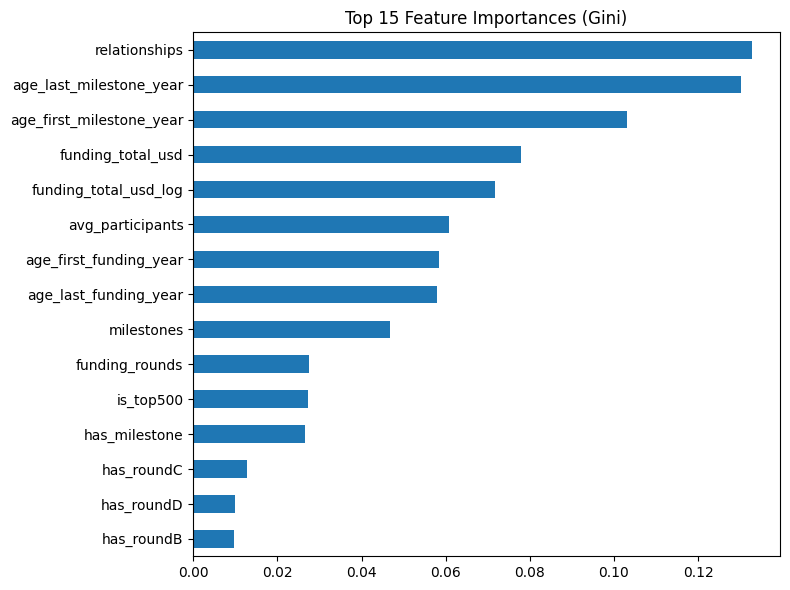

In [14]:
plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances (Gini)")
plt.tight_layout()
plt.show()

In [15]:
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_importances = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
perm_importances.head(15)

relationships       5.945946e-03
is_MA               1.621622e-03
is_mobile           1.621622e-03
state_code_MA       1.081081e-03
is_othercategory    1.081081e-03
has_angel           5.405405e-04
state_code_WA       1.110223e-17
is_enterprise       1.110223e-17
state_code_WV       0.000000e+00
state_code_UT       0.000000e+00
state_code_TN       0.000000e+00
is_ecommerce        0.000000e+00
state_code_CA       0.000000e+00
state_code_AZ       0.000000e+00
is_consulting       0.000000e+00
dtype: float64

## 10. Takeaways

- Model achieves **~75% accuracy** and **~0.83 ROC AUC** — solid, meaningful signal above random guessing
- `relationships` (professional network size) is the most robust predictor — it survives both importance tests
- Milestone timing and funding amount are secondary but real drivers
- Many features are correlated (funding rounds vs funding total, milestones vs milestone timing), which is why Gini and permutation importance disagree on the lower-ranked features — a reminder to never trust a single importance method blindly